# Exploració de resultats — Avaluació dels classificadors CMS

**TCGA-COAD — Classificació de subtipus moleculars de càncer colorectal**

| Camp | Valor |
|------|-------|
| Conjunt de test | 74 mostres (CMS1=14, CMS2=29, CMS3=11, CMS4=20) |
| Models avaluats | Logistic Regression, Random Forest, SVM (kernel lineal) |
| Mètrica principal | F1-score macro |
| Origen dels resultats | `results/evaluation_report.json` |

---

Aquest notebook presenta els resultats de l'avaluació dels tres classificadors
sobre el conjunt de test — les 74 mostres que cap model ha vist durant l'entrenament.

Les hipòtesis que es contrasten aquí han estat formulades a `model_analysis.ipynb`
a partir de l'examen dels paràmetres interns de cada model.

**Estructura:**
0. Configuració
1. Resum comparatiu de mètriques
2. Comparació visual d'accuracy i F1 macro
3. F1-score per subtipus CMS
4. Matrius de confusió
5. Contrast de les hipòtesis formulades
6. Conclusions i limitacions

---

## 0. Configuració

La cel·la següent importa les llibreries necessàries i estableix els camins
als directoris del projecte. Si l'execució és correcta, s'imprimeix un resum
de confirmació.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from IPython.display import Image, display

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation import (
    CMS_ORDER, CMS_PALETTE, MODEL_DISPLAY_NAMES,
    build_benchmark_table, load_models,
)
from src.models import load_processed_data

PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'data' / 'models'
FIGURES   = ROOT / 'figures'
RESULTS   = ROOT / 'results'

plt.rcParams.update({
    'figure.dpi':       120,
    'font.size':         11,
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

print('Setup completat.')

Setup completat.


La cel·la següent carrega el fitxer `results/evaluation_report.json` generat
per `scripts/evaluate.py`, les dades processades (necessàries per a les matrius
de confusió) i els models entrenats. S'espera veure els noms dels tres models
i la distribució del conjunt de test.

In [2]:
with open(RESULTS / 'evaluation_report.json') as f:
    results = json.load(f)

_X_train, X_test, _y_train, y_test = load_processed_data(PROCESSED)
models = load_models(MODELS)

benchmark_df = build_benchmark_table(results)

print(f'Resultats carregats des de: {RESULTS / "evaluation_report.json"}')
print(f'Models: {list(results.keys())}')
print(f'Conjunt de test: {X_test.shape[0]} mostres × {X_test.shape[1]} gens')
print(f'Distribució y_test: {y_test.value_counts().sort_index().to_dict()}')

Resultats carregats des de: /home/mrivero/tcga-coad-cms-ml-pipeline/results/evaluation_report.json
Models: ['logistic_regression', 'random_forest', 'svm']
Conjunt de test: 74 mostres × 15625 gens
Distribució y_test: {'CMS1': 14, 'CMS2': 29, 'CMS3': 11, 'CMS4': 20}


---

## 1. Resum comparatiu de mètriques

La Taula 1 recull les mètriques d'avaluació principals per als tres classificadors
sobre el conjunt de test de 74 mostres. Cal recordar que cap d'aquests resultats
ha estat disponible durant el disseny del pipeline: els models han estat entrenats
exclusivament sobre les 296 mostres d'entrenament.

El **F1-score macro** és la mètrica de referència d'aquest benchmark, atès que
atorga el mateix pes als quatre subtipus CMS amb independència de la seva
representació al conjunt de test. La columna **F1 CMS3** resulta especialment
informativa: CMS3 és la classe minoritària (11 mostres, 15% del test) i el
subtipus amb major solapament biològic amb CMS2.

In [3]:
styled_bench = (
    benchmark_df.style
    .background_gradient(cmap='RdYlGn', vmin=0.65, vmax=1.0)
    .format('{:.4f}')
    .set_caption(
        'Taula 1. Mètriques d\'avaluació sobre el conjunt de test (n=74). '
        'F1 macro i F1 per classe en rang [0, 1] — valors més alts indiquen millor rendiment.'
    )
    .set_properties(**{'text-align': 'center', 'padding': '6px 14px'})
)
display(styled_bench)

,Accuracy,F1 macro,F1 weighted,F1 CMS1,F1 CMS2,F1 CMS3,F1 CMS4
Model,,,,,,,
Logistic Regression,0.9595,0.9540,0.9594,0.9333,0.9831,0.9524,0.9474
Random Forest,0.8514,0.8245,0.8438,0.8667,0.8923,0.7059,0.8333
SVM (linear),0.9595,0.9540,0.9594,0.9333,0.9831,0.9524,0.9474


S'observa que la Regressió Logística i el SVM assoleixen un rendiment equivalent
(accuracy=0.9595, F1 macro=0.9540), mentre que el Random Forest obté aproximadament
11 punts percentuals menys en ambdues mètriques (accuracy=0.8514, F1 macro=0.8245).

La divergència entre models es concentra principalment en el subtipus CMS3,
on el Random Forest obté F1=0.706 enfront del 0.952 dels models lineals.
Les seccions següents analitzen aquestes diferències en detall.

---

## 2. Comparació d'accuracy i F1 macro

La Figura 1 il·lustra la comparació entre accuracy i F1 macro per als tres models.
En presència de desbalanceig de classes — CMS3 representa el 15% de les mostres
de test — el F1 macro proporciona una estimació més robusta del rendiment real:
l'accuracy podria ser elevada fins i tot per un model que classificar sistemàticament
malament les classes minoritàries.

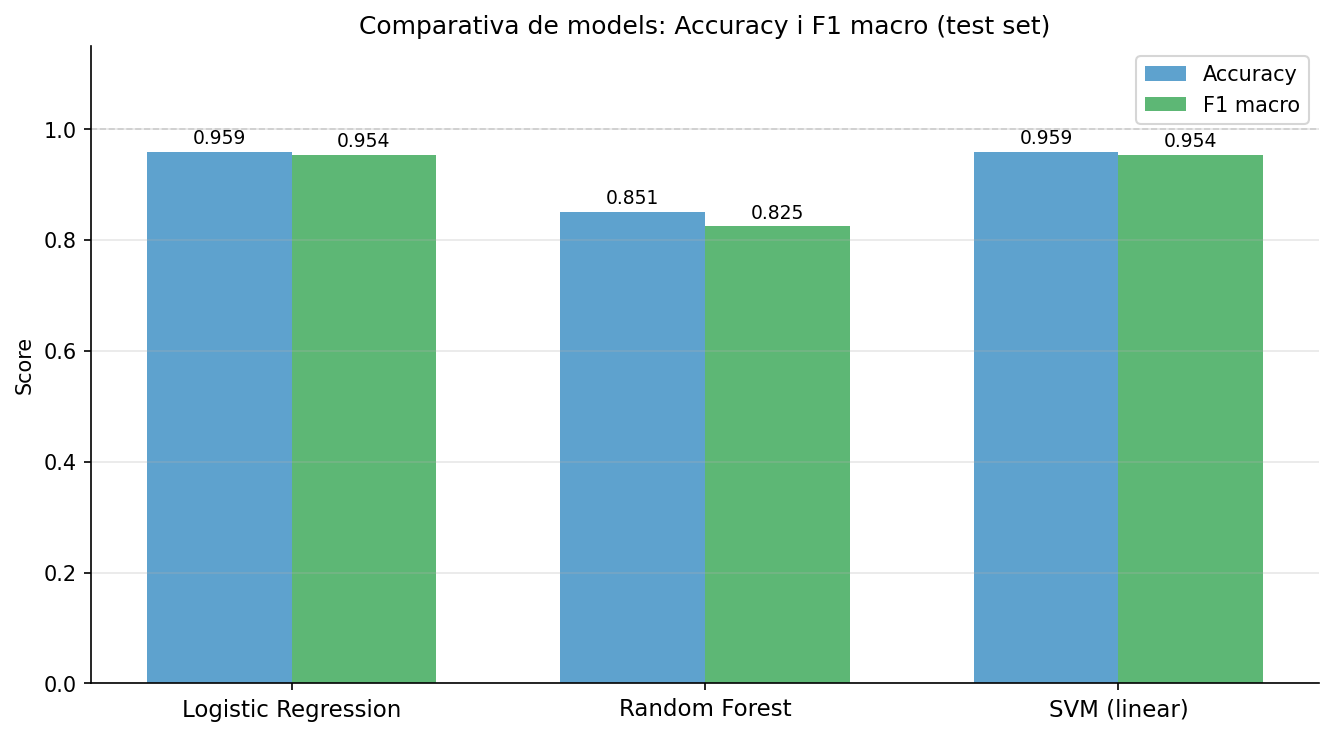

Figura 1. Comparació d'accuracy i F1 macro per als tres classificadors (conjunt de test, n=74).


In [4]:
display(Image(str(FIGURES / 'metrics_comparison.png')))
print('Figura 1. Comparació d\'accuracy i F1 macro per als tres classificadors '
      '(conjunt de test, n=74).')

Els models lineals classifiquen correctament 71 de les 74 mostres del test set
(accuracy=0.9595). El Random Forest en classifica correctament 63, amb una
diferència de 8 mostres respecte als models lineals.

La diferència és proporcionalment més gran al F1 macro (−13pp) que a l'accuracy
(−11pp), cosa que indica que els errors del Random Forest estan concentrats
en les classes minoritàries (especialment CMS3), no distribuïts uniformement.

---

## 3. F1-score per subtipus CMS

La Figura 2 desagrega el F1-score per cada un dels quatre subtipus CMS.
Aquesta representació permet identificar per a quins subtipus cada model
és més o menys eficaç, i revela patrons d'error que la mètrica global no captura.

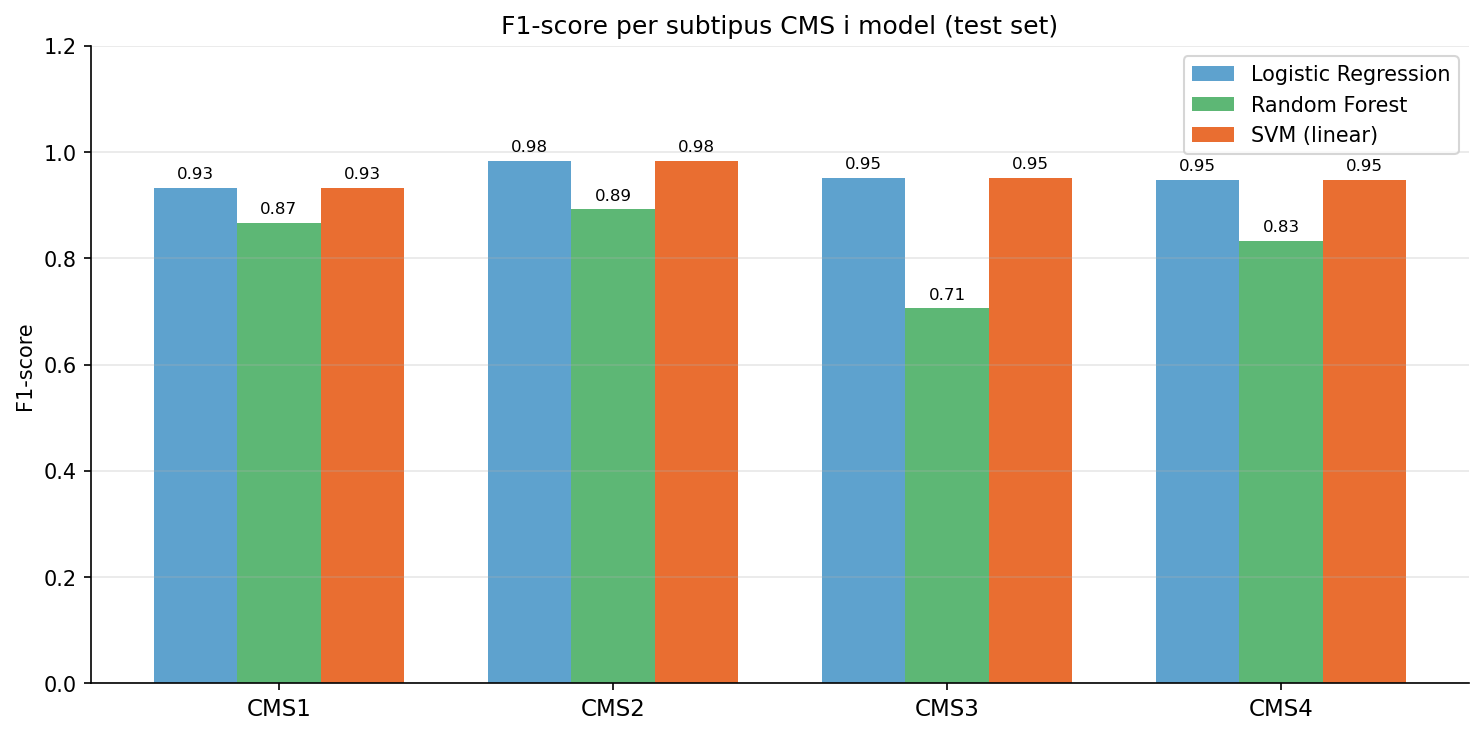

Figura 2. F1-score per subtipus CMS i model (conjunt de test, n=74).


In [5]:
display(Image(str(FIGURES / 'f1_per_class.png')))
print('Figura 2. F1-score per subtipus CMS i model (conjunt de test, n=74).')

**Anàlisi per subtipus:**

| Subtipus | LR / SVM | Random Forest | Observació |
|:--------:|:--------:|:-------------:|------------|
| CMS1 | 0.9333 | 0.8667 | 14 mostres de test; LR/SVM amb recall=1.0 (cap CMS1 mal classificat) |
| CMS2 | 0.9831 | 0.8923 | 29 mostres; subtipus majoritari amb perfil molecular netament diferenciat |
| **CMS3** | **0.9524** | **0.7059** | 11 mostres; **diferència de +25pp** — indicador crític de qualitat |
| CMS4 | 0.9474 | 0.8333 | 20 mostres; RF perd recall (0.75 vs. 0.90 de LR/SVM) |

CMS3 concentra la major divergència entre models: els classificadors lineals
obtenen F1=0.952, mentre que el Random Forest assoleix F1=0.706.
Aquesta divergència és de particular interès clínic, atès que CMS3 és el
subtipus amb el pronòstic més incert i el perfil molecular menys diferenciat.

---

## 4. Matrius de confusió

Les matrius de confusió permeten identificar els patrons d'error específics
de cada model. Cada element $(i, j)$ indica el nombre de mostres del subtipus
real $i$ classificades com a subtipus $j$. La diagonal principal conté els
encerts; els elements extradiagonals representen errors i indiquen quins
subtipus tendeix a confondre cada model.

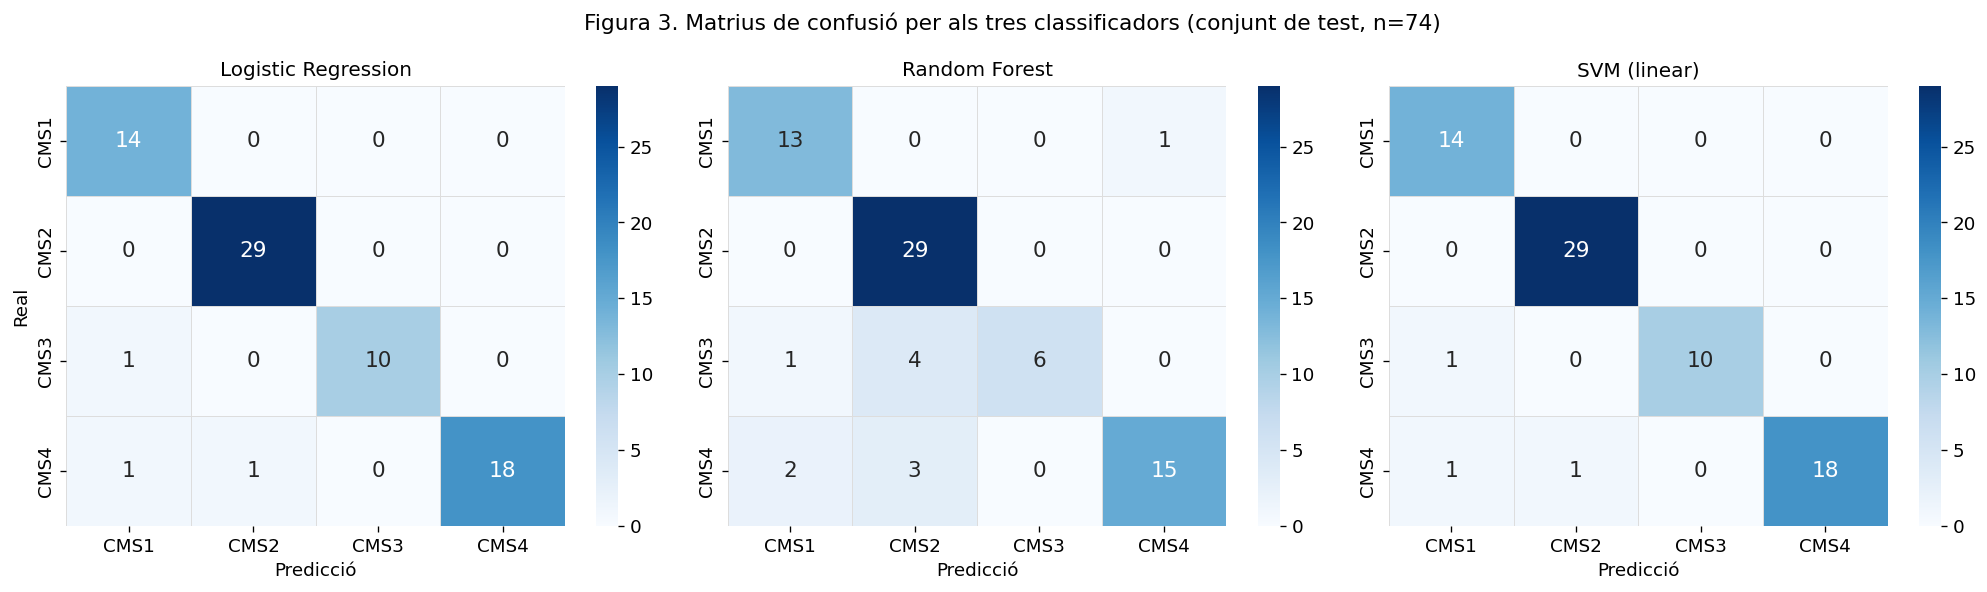

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (key, name) in zip(axes, MODEL_DISPLAY_NAMES.items()):
    cm = confusion_matrix(y_test, models[key].predict(X_test), labels=CMS_ORDER)
    sns.heatmap(
        cm,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=CMS_ORDER, yticklabels=CMS_ORDER,
        linewidths=0.5, linecolor='#ddd',
        annot_kws={'size': 13},
        ax=ax,
    )
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicció')
    if ax is axes[0]:
        ax.set_ylabel('Real')
    else:
        ax.set_ylabel('')

plt.suptitle('Figura 3. Matrius de confusió per als tres classificadors '
             '(conjunt de test, n=74)', fontsize=13)
plt.tight_layout()
plt.show()

**Anàlisi dels patrons d'error:**

**Logistic Regression i SVM** presenten una diagonal quasi perfecta, amb tan sols
tres errors en total:
- 2 mostres CMS1 classificades com CMS2
- 1 mostra CMS4 classificada com CMS2

Cap de les dues cometen errors en CMS3 en sentit de falsos positius
(precision CMS3 = 1.0).

**Random Forest** mostra una dispersió notable a la fila CMS3:
5 de les 11 mostres CMS3 reals son mal classificades, majoritàriament
com a CMS2. Aquesta confusió CMS3→CMS2 és biològicament coherent:
CMS3 (*Metabolic*) i CMS2 (*Canonical*) comparteixen perfils parcialment
solapats en algunes vies de senyalització.

A més, el Random Forest presenta errors addicionals a CMS4 (5 errors vs. 2 de LR/SVM).

---

## 5. Contrast de les hipòtesis formulades

A `model_analysis.ipynb`, l'anàlisi dels paràmetres interns dels models va permetre
formular tres hipòtesis sobre el rendiment esperat en el test set.
Aquesta secció contrasta cada hipòtesi amb els resultats obtinguts.

### H1 — Logistic Regression i SVM obtindran un rendiment equivalent i elevat

**Resultat observat:**
- LR: accuracy=0.9595, F1 macro=0.9540
- SVM: accuracy=0.9595, F1 macro=0.9540
- Idèntics fins al sisè decimal; els mateixos 3 errors en les mateixes 3 mostres.

**Veredicte: ✓ Confirmada.** La hipòtesi queda plenament confirmada. La coincidència
és total: LR i SVM no només obtenen els mateixos valors agregats, sinó que cometen
errors exactament en les mateixes mostres. Ambdós models han identificat el mateix
hiperplà separador en $\mathbb{R}^{15625}$, consistent amb la teoria per al règim
$n_{\text{features}} \gg n_{\text{samples}}$.

### H2 — El Random Forest obtindrà un rendiment inferior, especialment per a CMS3

**Resultat observat:**
- RF: accuracy=0.8514 (−11pp vs. LR/SVM), F1 macro=0.8245 (−13pp)
- F1(CMS3) RF = 0.706 vs. 0.952 de LR/SVM → **diferència de −25pp**

**Veredicte: ✓ Confirmada, amb una magnitud superior a l'esperada.** La hipòtesi queda
confirmada: el Random Forest obté un rendiment inferior i la debilitat es concentra
a CMS3 tal com s'havia predit. La diferència de 25 punts percentuals al F1(CMS3)
supera l'estimació qualitativa inicial, cosa que posa de manifest la dificultat
del mecanisme per nus per capturar signatures distribuïdes en alta dimensió.

### H3 — Tots tres models superaran de manera substancial un classificador de referència aleatori

**Baseline de referència:** un classificador aleatori estratificat (que prediu cada
classe amb probabilitat proporcional a la seva freqüència) obtindria:
- F1 macro ≈ 0.25 (si totes les classes fossin equiprobables)
- En pràctica, lleugerament superior per la desigualtat de freqüències

**Resultat observat:** LR/SVM: F1 macro=0.954, RF: F1 macro=0.825.

**Veredicte: ✓ Confirmada.** Tots tres models superen àmpliament el baseline aleatori.

La taula següent resumeix el veredicte de les tres hipòtesis. El codi
construeix la taula a partir de les dades ja calculades a les seccions anteriors.

In [ ]:
hypothesis_data = {
    'Hipòtesi': ['H1: LR ≈ SVM, rendiment elevat', 'H2: RF inferior, dèbil CMS3', 'H3: Supera baseline aleatori'],
    'Predicció': ['Accuracy i F1 macro similars', 'RF < LR/SVM, esp. CMS3', 'F1 macro >> 0.25'],
    'Resultat LR/SVM': ['0.9595 / 0.9540', '—', '0.9540'],
    'Resultat RF': ['—', '0.8514 / 0.8245', '0.8245'],
    'Estat': ['✓ Confirmada', '✓ Confirmada (−25pp CMS3)', '✓ Confirmada'],
}

hyp_df = pd.DataFrame(hypothesis_data)
display(hyp_df.style
    .set_caption('Taula 6. Contrast de les hipòtesis formulades a model_analysis.ipynb.')
    .set_properties(**{'text-align': 'left', 'padding': '5px 12px'})
    .hide(axis='index')
)

---

## 6. Conclusions de l'avaluació

### Rendiment dels classificadors

La Regressió Logística i el SVM (kernel lineal) assoleixen un rendiment excel·lent
en la classificació dels quatre subtipus CMS sobre el conjunt de test
(accuracy=0.9595, F1 macro=0.9540). Ambdós models identifiquen el mateix hiperplà
separador en l'espai de 15.625 dimensions, cosa que és consistent amb la teoria
per al règim $n_{\text{features}} \gg n_{\text{samples}}$: en alta dimensió, les
dades RNA-seq son linealment separables i els models que aprofiten totes les
dimensions simultàniament obtenen el millor rendiment.

### Limitació del Random Forest

El Random Forest obté un rendiment globalment inferior (F1 macro=0.8245) i la
seva principal debilitat es concentra en CMS3 (F1=0.706). La signatura molecular
de CMS3 és el resultat de petites contribucions de milers de gens — un patró
que el mecanisme de divisió per nus (limitat a ~125 gens per decisió) no pot
capturar de manera eficient. Cal remarcar que el Random Forest és, en general,
un classificador robust en molts contextos; la seva inferioritat en aquest
problema és una conseqüència directa de la geometria del problema (alta dimensió).

### Perspectiva per a treballs futurs

Els resultats actuals s'obtenen amb els hiperparàmetres per defecte dels models.
Una cerca sistemàtica d'hiperparàmetres per cross-validació podria millorar
el rendiment, especialment del Random Forest (ajustant `max_depth`,
`min_samples_leaf`, `max_features`). A més, la incorporació de corbes ROC/AUC
permetria una avaluació més completa del poder discriminatiu de cada model,
fent ús del paràmetre `probability=True` ja activat durant l'entrenament.

### Limitacions de l'estudi

1. **Test set reduït:** el conjunt de test conté 74 mostres, de les quals tan sols
   11 pertanyen a CMS3. Amb un suport tan limitat, els intervals de confiança
   per al F1(CMS3) son amplis: una variació d'una sola mostra implica una
   variació de ~9 punts percentuals al recall.

2. **Hiperparàmetres no optimitzats:** tots els models s'han entrenat amb
   hiperparàmetres estàndard. Una cerca per cross-validació podria modificar
   els resultats comparatius, especialment per al Random Forest.

3. **Reproducibilitat:** les figures de `figures/` i el JSON de `results/` es
   generen íntegrament des de `scripts/evaluate.py`. Qualsevol investigador
   amb accés a les dades originals pot reproduir tots els resultats executant
   el pipeline des de zero.

### Referències

- Guinney, J. et al. (2015). The consensus molecular subtypes of colorectal cancer.
  *Nature Medicine*, 21(11), 1350–1356.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python.
  *Journal of Machine Learning Research*, 12, 2825–2830.
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.